In [19]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [26]:
from pathlib import Path
import platform
import h5py
import beautifuljason as bjason

import numpy as np
import pandas as pd

from rdkit import Chem
import pandas as pd
from rdkit.Chem.rdMolDescriptors import CalcMolFormula

from matplotlib import pyplot as plt

In [27]:
%matplotlib inline

In [28]:
if platform.system() == 'Darwin':
    fn = Path("/Users/vsmw51/Dropbox/alpha_ionone2.jjh5")

In [29]:
fn.exists()

True

In [30]:
# import h5py

molfilestr = "error"

with h5py.File(fn, 'r') as fp:
    try:
        mol_info = fp['JasonDocument/Molecules/Molecules/0']

        molfilestr = mol_info.attrs['sdfile']

    except KeyError:
        print("Key not found")
if isinstance(molfilestr, bytes):
    molfilestr = molfilestr.decode('utf-8')
print(molfilestr)


  JASON   

 14 14  0  0  0  0  0  0  0  0999 V2000
    4.7546    0.1821    0.0000 C   0  0  0  0  0  0
    2.1565    0.1821    0.0000 C   0  0  0  0  0  0
    3.4556    0.9321    0.0000 C   0  0  0  0  0  0
    0.8575    2.4321    0.0000 C   0  0  0  0  0  0
   -0.4416    3.1821    0.0000 C   0  0  0  0  0  0
    0.8575    0.9321    0.0000 C   0  0  0  0  0  0
   -0.4416    0.1821    0.0000 C   0  0  0  0  0  0
   -1.7407    0.9321    0.0000 C   0  0  0  0  0  0
    0.5226   -0.9670    0.0000 C   0  0  0  0  0  0
    6.0537    0.9321    0.0000 C   0  0  0  0  0  0
   -1.4057   -0.9670    0.0000 C   0  0  0  0  0  0
   -1.7407    2.4321    0.0000 C   0  0  0  0  0  0
    2.1565    3.1821    0.0000 C   0  0  0  0  0  0
    4.7546   -1.3179    0.0000 O   0  0  0  0  0  0
  1 10  1  0  0  0  0
  1  3  1  0  0  0  0
  1 14  2  0  0  0  0
  2  6  1  0  0  0  0
  2  3  2  0  0  0  0
  4 13  1  0  0  0  0
  4  6  1  0  0  0  0
  4  5  2  0  0  0  0
  5 12  1  0  0  0  0
  6  7  1  0  0  0  0

In [31]:
# create a function to read the molfilestr form the h5 file
def read_molfilestr_from_h5(fn):
    with h5py.File(fn, 'r') as fp:
        try:
            mol_info = fp['JasonDocument/Molecules/Molecules/0']

            molfilestr = mol_info.attrs['sdfile']

        except KeyError:
            print("Key not found")
            return None
    if isinstance(molfilestr, bytes):
        molfilestr = molfilestr.decode('utf-8')
    return molfilestr

molfilestr = read_molfilestr_from_h5(fn)
print(molfilestr)


  JASON   

 14 14  0  0  0  0  0  0  0  0999 V2000
    4.7546    0.1821    0.0000 C   0  0  0  0  0  0
    2.1565    0.1821    0.0000 C   0  0  0  0  0  0
    3.4556    0.9321    0.0000 C   0  0  0  0  0  0
    0.8575    2.4321    0.0000 C   0  0  0  0  0  0
   -0.4416    3.1821    0.0000 C   0  0  0  0  0  0
    0.8575    0.9321    0.0000 C   0  0  0  0  0  0
   -0.4416    0.1821    0.0000 C   0  0  0  0  0  0
   -1.7407    0.9321    0.0000 C   0  0  0  0  0  0
    0.5226   -0.9670    0.0000 C   0  0  0  0  0  0
    6.0537    0.9321    0.0000 C   0  0  0  0  0  0
   -1.4057   -0.9670    0.0000 C   0  0  0  0  0  0
   -1.7407    2.4321    0.0000 C   0  0  0  0  0  0
    2.1565    3.1821    0.0000 C   0  0  0  0  0  0
    4.7546   -1.3179    0.0000 O   0  0  0  0  0  0
  1 10  1  0  0  0  0
  1  3  1  0  0  0  0
  1 14  2  0  0  0  0
  2  6  1  0  0  0  0
  2  3  2  0  0  0  0
  4 13  1  0  0  0  0
  4  6  1  0  0  0  0
  4  5  2  0  0  0  0
  5 12  1  0  0  0  0
  6  7  1  0  0  0  0

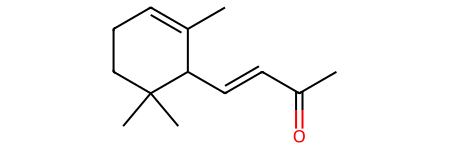

In [33]:
# create rdkit mol object from molfilestr
rdkit_mol = Chem.MolFromMolBlock(molfilestr)
rdkit_mol

In [9]:
def readJEOLmolecule(fn):    
    with h5py.File(fn, 'r') as fp:
        try:
            mol_data = fp['JasonDocument/Molecules/Molecules/0/Atoms']
            atom_list = []
            for i in range(len(mol_data)):
                atom_info = {key: mol_data[str(i)].attrs.get(key, None) for key in mol_data[str(i)].attrs.keys()}
                atom_list.append(atom_info)
            atoms_df = pd.DataFrame(atom_list)
            # add 1 to index
            # atoms_df.index += 1
            # add Z axis all 0
            atoms_df['Z'] = 0.0
        except KeyError as e:
            print(f"KeyError: {e}")

    return atoms_df
atoms_df = readJEOLmolecule(fn)
atoms_df

,El,NB.Conn,NB.Num,X,Y,nH,Z
0,6,"[1, 1, 2]","[9, 2, 13]",4.754556,0.182120,0,0.0
1,6,"[1, 2]","[5, 2]",2.156452,0.182120,1,0.0
2,6,"[2, 1]","[1, 0]",3.455554,0.932125,1,0.0
3,6,"[1, 513, 514]","[12, 5, 4]",0.857451,2.432119,0,0.0
4,6,"[514, 513]","[3, 11]",-0.441555,3.182124,1,0.0
5,6,"[513, 1, 513]","[6, 1, 3]",0.857451,0.932125,1,0.0
6,6,"[1, 1, 513, 513]","[10, 8, 7, 5]",-0.441555,0.182120,0,0.0
7,6,"[513, 513]","[6, 11]",-1.740650,0.932125,2,0.0
8,6,[1],[6],0.522561,-0.966971,3,0.0
9,6,[1],[0],6.053656,0.932125,3,0.0


In [6]:


def dataframe_to_rdkit_molecule(df):
    """
    Convert a pandas DataFrame with molecular structure data directly to RDKit molecule
    
    Args:
        df: DataFrame with columns ['El', 'NB.Conn', 'NB.Num', 'X', 'Y', 'nH', 'Z']
    
    Returns:
        rdkit.Chem.Mol: RDKit molecule object or None if creation failed
    """
    
    try:
        # Create an editable molecule object
        mol = Chem.EditableMol(Chem.Mol())
        
        # Reset index to ensure proper atom numbering
        mol_df = df.copy().reset_index(drop=True)
        
        # Handle missing Z coordinates
        if 'Z' not in mol_df.columns:
            mol_df['Z'] = 0.0
        mol_df['Z'] = mol_df['Z'].fillna(0.0)
        
        print(f"Adding {len(mol_df)} atoms to molecule...")
        
        # Step 1: Add all atoms
        atom_indices = {}
        for idx, row in mol_df.iterrows():
            element_num = int(row['El'])
            
            # Create atom with the correct element
            atom = Chem.Atom(element_num)
            
            # Add atom to molecule
            atom_idx = mol.AddAtom(atom)
            atom_indices[idx] = atom_idx
            
            element_symbol = atom.GetSymbol()
            print(f"   Added atom {idx}: {element_symbol} (atomic #{element_num}) at RDKit index {atom_idx}")
        
        print(f"\nAdding bonds...")
        
        # Step 2: Add bonds based on connectivity
        bonds_added = set()  # Track bonds to avoid duplicates
        bond_count = 0
        
        for idx, row in mol_df.iterrows():
            rdkit_atom_idx = atom_indices[idx]
            
            # Get connection data
            nb_num = row.get('NB.Num')
            nb_conn = row.get('NB.Conn')
            
            # Check if connection data exists
            nb_num_valid = nb_num is not None and not (isinstance(nb_num, float) and pd.isna(nb_num))
            nb_conn_valid = nb_conn is not None and not (isinstance(nb_conn, float) and pd.isna(nb_conn))
            
            if nb_num_valid and nb_conn_valid:
                try:
                    # Handle numpy arrays and ensure we have lists
                    if isinstance(nb_num, np.ndarray):
                        nb_num = nb_num.tolist()
                    elif not isinstance(nb_num, list):
                        nb_num = [nb_num]
                        
                    if isinstance(nb_conn, np.ndarray):
                        nb_conn = nb_conn.tolist()
                    elif not isinstance(nb_conn, list):
                        nb_conn = [nb_conn]
                    
                    # Process each connection
                    for i, connected_atom in enumerate(nb_num):
                        if (connected_atom is not None and 
                            not (isinstance(connected_atom, float) and pd.isna(connected_atom)) and 
                            connected_atom != ''):
                            
                            try:
                                connected_df_idx = int(float(connected_atom))
                                
                                # Skip self-connections
                                if connected_df_idx == idx:
                                    continue
                                
                                # Check if connected atom exists in our dataframe
                                if connected_df_idx not in atom_indices:
                                    print(f"   Warning: Connected atom {connected_df_idx} not found in dataframe")
                                    continue
                                
                                connected_rdkit_idx = atom_indices[connected_df_idx]
                                
                                # Avoid duplicate bonds
                                bond_pair = tuple(sorted([rdkit_atom_idx, connected_rdkit_idx]))
                                if bond_pair not in bonds_added:
                                    
                                    # Get bond order
                                    if i < len(nb_conn):
                                        bond_order = nb_conn[i]
                                    else:
                                        bond_order = 1
                                    
                                    # Convert bond order to RDKit bond type
                                    if bond_order == 1:
                                        rdkit_bond_type = Chem.BondType.SINGLE
                                        bond_name = "SINGLE"
                                    elif bond_order == 2:
                                        rdkit_bond_type = Chem.BondType.DOUBLE
                                        bond_name = "DOUBLE"
                                    elif bond_order == 3:
                                        rdkit_bond_type = Chem.BondType.TRIPLE
                                        bond_name = "TRIPLE"
                                    elif bond_order == 513:  # Aromatic
                                        rdkit_bond_type = Chem.BondType.AROMATIC
                                        bond_name = "AROMATIC"
                                    elif bond_order == 514:  # Double bond
                                        rdkit_bond_type = Chem.BondType.DOUBLE
                                        bond_name = "DOUBLE (from 514)"
                                    else:
                                        # Default to single bond for unknown types
                                        rdkit_bond_type = Chem.BondType.SINGLE
                                        bond_name = f"SINGLE (from unknown {bond_order})"
                                    
                                    # Add the bond
                                    mol.AddBond(rdkit_atom_idx, connected_rdkit_idx, rdkit_bond_type)
                                    bonds_added.add(bond_pair)
                                    bond_count += 1
                                    
                                    print(f"   Added bond {bond_count}: Atom{idx}({rdkit_atom_idx}) - Atom{connected_df_idx}({connected_rdkit_idx}) [{bond_name}]")
                                    
                            except (ValueError, TypeError) as e:
                                print(f"   Warning: Could not parse connection {connected_atom} for atom {idx}: {e}")
                                continue
                                
                except Exception as e:
                    print(f"   Warning: Error processing connections for atom {idx}: {e}")
                    continue
        
        print(f"\nTotal bonds added: {bond_count}")
        
        # Step 3: Convert to final molecule and add 2D coordinates
        final_mol = mol.GetMol()
        
        # Add 2D coordinates (ignoring Z since it's typically 0 for 2D molecules)
        if all(col in mol_df.columns for col in ['X', 'Y']):
            print("Adding 2D coordinates...")
            conf = Chem.Conformer(len(mol_df))
            conf.Set3D(False)  # Mark this as a 2D conformer
            
            for idx, row in mol_df.iterrows():
                rdkit_idx = atom_indices[idx]
                x, y = float(row['X']), float(row['Y'])
                # For 2D molecules, set Z to 0
                conf.SetAtomPosition(rdkit_idx, (x, y, 0.0))
            
            final_mol.AddConformer(conf)
            print("2D coordinates added successfully")
        else:
            print("X and/or Y coordinates not found - molecule will have no coordinates")
        
        # Step 4: Sanitize the molecule
        print("\nSanitizing molecule...")
        try:
            Chem.SanitizeMol(final_mol)
            print("Molecule sanitized successfully!")
            return final_mol
            
        except Exception as sanitize_error:
            print(f"Sanitization failed: {sanitize_error}")
            print("Trying with less strict sanitization...")
            
            # Try sanitization with specific operations
            try:
                sanitize_ops = (Chem.SanitizeFlags.SANITIZE_FINDRADICALS |
                               Chem.SanitizeFlags.SANITIZE_KEKULIZE |
                               Chem.SanitizeFlags.SANITIZE_SETAROMATICITY |
                               Chem.SanitizeFlags.SANITIZE_SETCONJUGATION |
                               Chem.SanitizeFlags.SANITIZE_SETHYBRIDIZATION |
                               Chem.SanitizeFlags.SANITIZE_CLEANUPCHIRALITY)
                
                Chem.SanitizeMol(final_mol, sanitizeOps=sanitize_ops)
                print("Molecule sanitized with custom operations!")
                return final_mol

            except Exception as e2:
                print(f"Custom sanitization also failed: {e2}")
                print("Returning unsanitized molecule...")
                return final_mol

    except Exception as e:
        print(f"Error creating molecule: {e}")
        return None

def analyze_rdkit_molecule(mol, name="Molecule"):
    """
    Analyze the created RDKit molecule
    """
    if mol is None:
        print(f"Cannot analyze {name} - molecule is None")
        return
    
    print(f"\n=== Analysis of {name} ===")
    try:
        print(f"Molecular formula: {CalcMolFormula(mol)}")
    except:
        print("Molecular formula: Could not calculate")
    
    print(f"Number of atoms: {mol.GetNumAtoms()}")
    print(f"Number of bonds: {mol.GetNumBonds()}")
    
    try:
        smiles = Chem.MolToSmiles(mol)
        print(f"SMILES: {smiles}")
    except:
        print("SMILES: Could not generate")
    
    try:
        inchi = Chem.MolToInchi(mol)
        print(f"InChI: {inchi}")
    except:
        print("InChI: Could not generate")
    
    # Check for coordinates
    has_coords = mol.GetNumConformers() > 0
    is_2d = False
    if has_coords:
        conf = mol.GetConformer()
        is_2d = not conf.Is3D()
    
    print(f"Has coordinates: {has_coords}")
    if has_coords:
        print(f"Coordinate type: {'2D' if is_2d else '3D'}")
    
    print("\nAtom details:")
    for atom in mol.GetAtoms():
        print(f"  Atom {atom.GetIdx()}: {atom.GetSymbol()} (degree: {atom.GetDegree()}, "
              f"valence: {atom.GetTotalValence()}, aromatic: {atom.GetIsAromatic()})")
    
    print("\nBond details:")
    for bond in mol.GetBonds():
        begin_atom = bond.GetBeginAtom()
        end_atom = bond.GetEndAtom()
        bond_type = bond.GetBondType()
        is_aromatic = bond.GetIsAromatic()
        print(f"  {begin_atom.GetSymbol()}{begin_atom.GetIdx()} - "
              f"{end_atom.GetSymbol()}{end_atom.GetIdx()} "
              f"({bond_type}, aromatic: {is_aromatic})")

def test_with_sample_data():
    """
    Test with the provided sample data
    """
    sample_data = {
        'El': [6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 6, 8],
        'NB.Conn': [
            [1, 1, 2], [1, 2], [2, 1], [1, 513, 514], [514, 513], [513, 1, 513],
            [1, 1, 513, 513], [513, 513], [1], [1], [1], [513, 513], [1], [2]
        ],
        'NB.Num': [
            [9, 2, 13], [5, 2], [1, 0], [12, 5, 4], [3, 11], [6, 1, 3],
            [10, 8, 7, 5], [6, 11], [6], [0], [6], [7, 4], [3], [0]
        ],
        'X': [4.754556, 2.156452, 3.455554, 0.857451, -0.441555, 0.857451,
              -0.441555, -1.740650, 0.522561, 6.053656, -1.405747, -1.740650, 2.156452, 4.754556],
        'Y': [0.182120, 0.182120, 0.932125, 2.432119, 3.182124, 0.932125,
              0.182120, 0.932125, -0.966971, 0.932125, -0.966971, 2.432119, 3.182124, -1.317874],
        'nH': [0, 1, 1, 0, 1, 1, 0, 2, 3, 3, 3, 2, 3, 0],
        'Z': [0.0] * 14
    }
    
    return pd.DataFrame(sample_data)


Adding 14 atoms to molecule...
   Added atom 0: C (atomic #6) at RDKit index 0
   Added atom 1: C (atomic #6) at RDKit index 1
   Added atom 2: C (atomic #6) at RDKit index 2
   Added atom 3: C (atomic #6) at RDKit index 3
   Added atom 4: C (atomic #6) at RDKit index 4
   Added atom 5: C (atomic #6) at RDKit index 5
   Added atom 6: C (atomic #6) at RDKit index 6
   Added atom 7: C (atomic #6) at RDKit index 7
   Added atom 8: C (atomic #6) at RDKit index 8
   Added atom 9: C (atomic #6) at RDKit index 9
   Added atom 10: C (atomic #6) at RDKit index 10
   Added atom 11: C (atomic #6) at RDKit index 11
   Added atom 12: C (atomic #6) at RDKit index 12
   Added atom 13: O (atomic #8) at RDKit index 13

Adding bonds...
   Added bond 1: Atom0(0) - Atom9(9) [SINGLE]
   Added bond 2: Atom0(0) - Atom2(2) [SINGLE]
   Added bond 3: Atom0(0) - Atom13(13) [DOUBLE]
   Added bond 4: Atom1(1) - Atom5(5) [SINGLE]
   Added bond 5: Atom1(1) - Atom2(2) [DOUBLE]
   Added bond 6: Atom3(3) - Atom12(12) [

[19:59:57] Can't kekulize mol.  Unkekulized atoms: 4 5 7 11


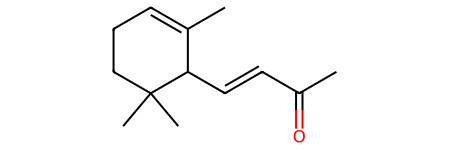

In [7]:
mol = dataframe_to_rdkit_molecule(atoms_df)
mol

In [8]:
molstr = Chem.MolToMolBlock(mol)

In [9]:
lines = molstr.split('\n')

In [37]:
def fix_stereo_info(molstr):
    lines = molstr.splitlines()
    for i, line in enumerate(lines):
        words = line.split()
        # Check if the line has 4 columns then we have reached the connectivity group
        if len(words) == 4:
            # If the last column is not '0', we have stereo info to fix
            if words[-1] != '0':
                print(f"Fixing stereo info in line {i}: {line}")
                # Fix the stereo info by replacing it with '0'
                if len(words[-1]) == 1:
                    line = line[:-1] + '0'
                elif len(words[-1]) == 2:
                    line = line[:-2] + '00'
                else:
                    print("Unexpected length:", len(words[-1]))
                # update the line in the original list
                lines[i] = line

    return "\n".join(lines)

In [38]:
molstr_new = fix_stereo_info(molstr)
print(molstr_new)

Fixing stereo info in line 22:   2  3  2  3

     RDKit          2D

 14 14  0  0  0  0  0  0  0  0999 V2000
    4.7546    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.1565    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.4556    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.8575    2.4321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4416    3.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.8575    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4416    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7407    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.5226   -0.9670    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.0537    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.4057   -0.9670    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7407    2.4321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.1565    3.1821    0.0000 C   0  0  0  0  0  0

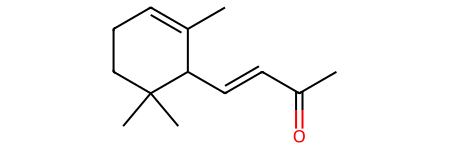

In [39]:
mol2 = Chem.MolFromMolBlock(new_molstr)
mol2

In [41]:
print("mol:", Chem.MolToSmiles(mol))
print("mol2:", Chem.MolToSmiles(mol2))


mol: CC(=O)C=CC1C(C)=CCCC1(C)C
mol2: CC(=O)/C=C/C1C(C)=CCCC1(C)C


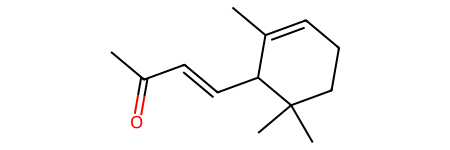

In [34]:
Chem.MolFromSmiles('CC(=O)C=CC1C(C)=CCCC1(C)C')

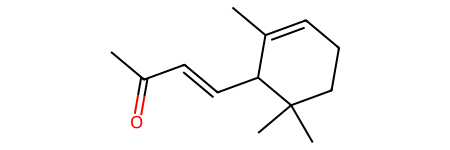

In [35]:
Chem.MolFromSmiles('CC(=O)/C=C/C1C(C)=CCCC1(C)C')

In [36]:
print(Chem.MolToMolBlock(mol2))


     RDKit          2D

 14 14  0  0  0  0  0  0  0  0999 V2000
    4.7546    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.1565    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    3.4556    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.8575    2.4321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4416    3.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.8575    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -0.4416    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7407    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    0.5226   -0.9670    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    6.0537    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.4057   -0.9670    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
   -1.7407    2.4321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    2.1565    3.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0
    4.7546   -1.3179    0

In [ ]:
# create smiles output for json
def create_smiles_for_json(mol: Chem.Mol) -> dict:
    """Creates a SMILES representation for JSON output.

    Args:
        mol (Chem.Mol): The molecule object.

    Returns:
        dict: A dictionary containing the SMILES representation.
    """
    smiles = {"datatype": "smiles",
              "count": 1,
              "data": {"0": Chem.MolToSmiles(mol)}
              }
    return smiles

# create molfile output for json
def create_molfile_for_json(mol: (Chem.Mol,str)) -> dict:
    """Creates a molfile representation for JSON output.

    Args:
        mol (Chem.Mol,str): The molecule object or molblock string.

    Returns:
        dict: A dictionary containing the molfile representation.
    """
    molblock = None
    if isinstance(mol, str):
        molblock  = mol
    elif isinstance(mol, Chem.Mol):
        molblock = Chem.MolToMolBlock(mol)
    if molblock is None:
            raise ValueError("Invalid mol block string provided")
    molblock = fix_stereo_info(molblock)
    molfile = {"datatype": "molfile",
              "count": 1,
              "data": {"0": molblock}
              }
    return molfile



In [53]:
create_smiles_for_json(mol)

{'datatype': 'smiles', 'count': 1, 'data': {'0': 'CC(=O)C=CC1C(C)=CCCC1(C)C'}}

In [54]:
create_molfile_for_json(mol)

Fixing stereo info in line 22:   2  3  2  3


{'datatype': 'molfile',
 'count': 1,
 'data': {'0': '\n     RDKit          2D\n\n 14 14  0  0  0  0  0  0  0  0999 V2000\n    4.7546    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.1565    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    3.4556    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8575    2.4321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.4416    3.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8575    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.4416    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.7407    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.5226   -0.9670    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    6.0537    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.4057   -0.9670    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.7407    2.4321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.1565    3.1821    0.

In [55]:
create_molfile_for_json(molstr)

Fixing stereo info in line 22:   2  3  2  3


{'datatype': 'molfile',
 'count': 1,
 'data': {'0': '\n     RDKit          2D\n\n 14 14  0  0  0  0  0  0  0  0999 V2000\n    4.7546    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.1565    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    3.4556    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8575    2.4321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.4416    3.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.8575    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -0.4416    0.1821    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.7407    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    0.5226   -0.9670    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    6.0537    0.9321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.4057   -0.9670    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n   -1.7407    2.4321    0.0000 C   0  0  0  0  0  0  0  0  0  0  0  0\n    2.1565    3.1821    0.

In [ ]:
# List of chemical element symbols indexed by atomic number (starting from 0)
symbolElements = (
    '',  # 0: No element
    'H', 'He', 'Li', 'Be', 'B', 'C', 'N', 'O', 'F', 'Ne',
    'Na', 'Mg', 'Al', 'Si', 'P', 'S', 'Cl', 'Ar', 'K', 'Ca',
    'Sc', 'Ti', 'V', 'Cr', 'Mn', 'Fe', 'Co', 'Ni', 'Cu', 'Zn',
    'Ga', 'Ge', 'As', 'Se', 'Br', 'Kr', 'Rb', 'Sr', 'Y', 'Zr',
    'Nb', 'Mo', 'Tc', 'Ru', 'Rh', 'Pd', 'Ag', 'Cd', 'In', 'Sn',
    'Sb', 'Te', 'I', 'Xe', 'Cs', 'Ba', 'La', 'Ce', 'Pr', 'Nd',
    'Pm', 'Sm', 'Eu', 'Gd', 'Tb', 'Dy', 'Ho', 'Er', 'Tm', 'Yb',
    'Lu', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt', 'Au', 'Hg',
    'Tl', 'Pb', 'Bi', 'Po', 'At', 'Rn', 'Fr', 'Ra', 'Ac', 'Th',
    'Pa', 'U', 'Np', 'Pu', 'Am', 'Cm', 'Bk', 'Cf', 'Es', 'Fm',
    'Md', 'No', 'Lr', 'Rf', 'Db', 'Sg', 'Bh', 'Hs', 'Mt', 'Ds',
    'Rg', 'Cn', 'Nh', 'Fl', 'Mc', 'Lv', 'Ts', 'Og'
)

In [ ]:
# create allatomsinfo output for json

def create_allatomsinfo(atoms_df):
    all_atoms_info = {
        "datatype": "allAtomsInfo",
        "count": atoms_df.shape[0],
        "data": {},
    }

    for idx, row in atoms_df.iterrows():
        symbol = symbolElements[row.get("El", 0)]
        atom_info = {
            "atom_idx": idx,
            "id": idx,
            "atomNumber": idx+1,
            "symbol": symbol,
            "numProtons": row.get("nH", None)
        }
        all_atoms_info["data"][str(idx)] = atom_info

    return all_atoms_info

create_allatomsinfo(atoms_df)

{'datatype': 'allAtomsInfo',
 'count': 14,
 'data': {'0': {'atom_idx': 0,
   'id': 0,
   'atomNumber': 1,
   'symbol': 'C',
   'numProtons': 0},
  '1': {'atom_idx': 1,
   'id': 1,
   'atomNumber': 2,
   'symbol': 'C',
   'numProtons': 1},
  '2': {'atom_idx': 2,
   'id': 2,
   'atomNumber': 3,
   'symbol': 'C',
   'numProtons': 1},
  '3': {'atom_idx': 3,
   'id': 3,
   'atomNumber': 4,
   'symbol': 'C',
   'numProtons': 0},
  '4': {'atom_idx': 4,
   'id': 4,
   'atomNumber': 5,
   'symbol': 'C',
   'numProtons': 1},
  '5': {'atom_idx': 5,
   'id': 5,
   'atomNumber': 6,
   'symbol': 'C',
   'numProtons': 1},
  '6': {'atom_idx': 6,
   'id': 6,
   'atomNumber': 7,
   'symbol': 'C',
   'numProtons': 0},
  '7': {'atom_idx': 7,
   'id': 7,
   'atomNumber': 8,
   'symbol': 'C',
   'numProtons': 2},
  '8': {'atom_idx': 8,
   'id': 8,
   'atomNumber': 9,
   'symbol': 'C',
   'numProtons': 3},
  '9': {'atom_idx': 9,
   'id': 9,
   'atomNumber': 10,
   'symbol': 'C',
   'numProtons': 3},
  '10': 

In [ ]:
# create carbonAtomsinfo output for json
def create_carbonAtomsinfo(atoms_df):
    carbon_atoms_info = {
        "datatype": "allAtomsInfo",
        "count": atoms_df.shape[0],
        "data": {},
    }

    for idx, row in atoms_df.iterrows():
        symbol = symbolElements[row.get("El", 0)]
        if symbol != "C":
            carbon_atoms_info["count"] -= 1
            continue
        atom_info = {
            "atom_idx": idx,
            "id": idx,
            "atomNumber": idx+1,
            "symbol": symbol,
            "numProtons": row.get("nH", None)
        }
        carbon_atoms_info["data"][str(idx)] = atom_info

    return carbon_atoms_info

create_carbonAtomsinfo(atoms_df)

{'datatype': 'allAtomsInfo',
 'count': 13,
 'data': {'0': {'atom_idx': 0,
   'id': 0,
   'atomNumber': 1,
   'symbol': 'C',
   'numProtons': 0},
  '1': {'atom_idx': 1,
   'id': 1,
   'atomNumber': 2,
   'symbol': 'C',
   'numProtons': 1},
  '2': {'atom_idx': 2,
   'id': 2,
   'atomNumber': 3,
   'symbol': 'C',
   'numProtons': 1},
  '3': {'atom_idx': 3,
   'id': 3,
   'atomNumber': 4,
   'symbol': 'C',
   'numProtons': 0},
  '4': {'atom_idx': 4,
   'id': 4,
   'atomNumber': 5,
   'symbol': 'C',
   'numProtons': 1},
  '5': {'atom_idx': 5,
   'id': 5,
   'atomNumber': 6,
   'symbol': 'C',
   'numProtons': 1},
  '6': {'atom_idx': 6,
   'id': 6,
   'atomNumber': 7,
   'symbol': 'C',
   'numProtons': 0},
  '7': {'atom_idx': 7,
   'id': 7,
   'atomNumber': 8,
   'symbol': 'C',
   'numProtons': 2},
  '8': {'atom_idx': 8,
   'id': 8,
   'atomNumber': 9,
   'symbol': 'C',
   'numProtons': 3},
  '9': {'atom_idx': 9,
   'id': 9,
   'atomNumber': 10,
   'symbol': 'C',
   'numProtons': 3},
  '10': 